# Help Desk Ticket SLA and Volume Forecasting

This capstone uses `data/raw/issues.csv` for two integrated workstreams: **(1) retrospective comparison of elapsed resolution time with project-configured SLA references by recorded priority; and (2) separate 7- and 30-day daily Ticket-volume forecasting experiments for capacity-planning research.** The 30-day forecast is a daily path, not one monthly total. The primary analysis includes `issue_type == Ticket` and creation dates on/after 2016-01-01 UTC, matching the period described in the accompanying source documentation.

**Important source caveat:** the CSV contains creation dates before 2016 despite the documentation's stated range. Those records are profiled but excluded from the primary scope. Dates without scoped Ticket rows are treated as zero arrivals in the forecasting series under an explicit completeness assumption that has not been independently verified. The source ends in March 2023 and cannot establish current operational performance.

The configured SLA references are project assumptions: Blocker/Highest → Critical (4h), High (8h), Medium (24h), Low/Lowest → Low (24h); `unknown` is excluded. The measured duration is calendar wall-clock time between creation and recorded resolution—not a verified business-hours SLA clock. Results are retrospective, not contractual compliance or a live warning model.

**Shared retrospective result across this notebook sequence:** among 16,735 eligible completed Tickets, 3,333 (19.9%) met the configured reference. By mapped priority: Critical 524/2,124 (24.7%); High 576/3,146 (18.3%); Medium 2,161/11,161 (19.4%); Low 72/304 (23.7%). Eligibility requires exact Ticket type, documented 2016+ scope, `Done`, known mapped priority, and valid nonnegative elapsed duration. Notebook 02 shows the detailed comparison; these same counts and caveats are the project-wide retrospective baseline.


# 06 | Reporting contract and data integration

Create a dashboard-ready split between retrospective SLA-reference results (3,333/16,735 eligible Tickets met; 19.9%) and the 7-/30-day arrival forecast experiments. Preserve field meaning, source scope, assumptions and operational status in the contract. This notebook does not call an LLM or present any endpoint as production-ready.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display
from src.issues_capstone import run_reporting
result = run_reporting()
print(result['contract'])
display(result['sla'])
display(result['forecast'])


{'project_name': 'Help Desk Ticket SLA and Volume Forecasting', 'primary_analysis': 'retrospective priority reference attainment and daily Ticket volume forecasting', 'source': 'data\\raw\\issues.csv', 'sla_reference': {'priority_mapping': {'Blocker': 'Critical', 'Highest': 'Critical', 'High': 'High', 'Medium': 'Medium', 'Low': 'Low', 'Lowest': 'Low'}, 'targets_hours': {'Critical': 4, 'High': 8, 'Medium': 24, 'Low': 24}, 'duration': 'Calendar wall-clock hours: issue_resolution_date minus issue_created; not a confirmed business-hours/pause-adjusted SLA clock.', 'policy_status': 'Not policy-validated. Priority mapping and target applicability require service-owner confirmation.'}, 'daily_volume_forecast': {'target': 'count of issue_type=Ticket records by issue_created calendar day', 'horizon_days': 30, 'evaluated_horizons_days': [7, 30], 'selected_models_by_horizon': {'7': {'selected_model': 'XGBoost autoregression (28-day lags)', 'validation_mae': 4.181157049978827, 'validation_metrics'

,priority,assessed_tickets,reference_met,median_elapsed_hours,p90_elapsed_hours,p95_elapsed_hours,reference_hours,reference_met_pct,reference_breach
0,Critical,2124,524,73.493472,958.538556,1465.956750,4.0,24.670433,1600
1,High,3146,576,112.619444,1172.855972,2181.999375,8.0,18.308964,2570
2,Low,304,72,170.996944,2116.562694,4786.611833,24.0,23.684211,232
3,Medium,11161,2161,171.545764,1357.650833,2307.073889,24.0,19.362064,9000
4,Overall,16735,3333,147.259722,1286.016915,2206.733465,NaN,19.916343,13402


,split,model,forecast_window_days,forecast_days,forecast_origins,MAE,RMSE,WAPE,sMAPE,signed_bias_actual_minus_forecast,validation_abs_error_p90,coverage_90_interval,interpretation
0,validation,Seasonal naive (same weekday last week),7,364,52,5.142857,7.473396,0.387497,0.572676,0.093407,12.000000,NaN,historical backtest; transfer to current opera...
1,validation,ETS (weekly additive),7,364,52,4.227266,5.790660,0.318511,0.547498,0.333868,8.801554,NaN,historical backtest; transfer to current opera...
2,validation,XGBoost autoregression (28-day lags),7,364,52,4.181157,6.020386,0.315036,0.541501,1.309540,9.359890,NaN,historical backtest; transfer to current opera...
3,validation,Ridge (MI-selected features + PCA),7,364,52,4.323507,6.293326,0.325762,0.548747,1.873757,9.491935,NaN,historical backtest; transfer to current opera...
4,test,Seasonal naive (same weekday last week),7,357,51,6.408964,9.830781,0.386030,0.528606,0.044818,12.000000,0.862745,historical backtest; transfer to current opera...
5,test,ETS (weekly additive),7,357,51,4.758324,7.398095,0.286607,0.447647,0.385932,8.801554,0.873950,historical backtest; transfer to current opera...
6,test,XGBoost autoregression (28-day lags),7,357,51,5.049222,7.722058,0.304129,0.490345,1.424021,9.359890,0.865546,historical backtest; transfer to current opera...
7,test,Ridge (MI-selected features + PCA),7,357,51,5.217716,8.006777,0.314278,0.457855,1.604747,9.491935,0.837535,historical backtest; transfer to current opera...
8,validation,Seasonal naive (same weekday last week),30,359,48,5.411806,7.803089,0.395704,0.607528,0.415972,13.000000,NaN,historical backtest; transfer to current opera...
9,validation,ETS (weekly additive),30,359,48,4.393815,6.088672,0.321270,0.534821,0.777126,9.125416,NaN,historical backtest; transfer to current opera...


## Power BI ready export folder

`output/issue_helpdesk/powerbi/` is a dedicated export folder ready to be opened in Power BI for both the after the fact SLA report and the volume forecast. It contains a ticket level SLA fact table, a priority dimension table, the daily actual and rolling forecast tables, a model comparison table, a `power_bi_dashboard_spec.json` describing pages, relationships and refresh steps, and a `screenshots/` subfolder with one sample image per report page. Every table and screenshot is rebuilt from `data/raw/issues.csv` and the persisted forecast tables each time `run_powerbi_export()` runs, so nothing is hardcoded to today's row counts or date range; a larger or refreshed source file flows through automatically.

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.issues_capstone import run_powerbi_export

powerbi_result = run_powerbi_export()
print(f"Power BI export folder: {powerbi_result['powerbi_dir']}")
print(f"fact_tickets_sla.csv rows: {powerbi_result['fact_tickets_sla_rows']}")
print(f"fact_daily_ticket_volume.csv rows: {powerbi_result['fact_daily_ticket_volume_rows']}")
print("Screenshots:")
for name, path in powerbi_result["screenshots"].items():
    print(f"  {name}: {path}")
sorted(p.name for p in (ROOT / powerbi_result["powerbi_dir"]).glob("*"))

Power BI export folder: output\issue_helpdesk\powerbi
fact_tickets_sla.csv rows: 16735
fact_daily_ticket_volume.csv rows: 2628
Screenshots:
  sla_attainment_report: output\issue_helpdesk\powerbi\screenshots\01_sla_attainment_report.png
  daily_volume_and_forecast: output\issue_helpdesk\powerbi\screenshots\02_daily_volume_and_forecast.png
  model_comparison: output\issue_helpdesk\powerbi\screenshots\03_model_comparison.png
  data_contract_and_caveats: output\issue_helpdesk\powerbi\screenshots\04_data_contract_and_caveats.png


['dashboard_data_contract.json',
 'dim_priority.csv',
 'fact_daily_ticket_volume.csv',
 'fact_tickets_sla.csv',
 'fact_volume_forecast.csv',
 'model_comparison_metrics.csv',
 'power_bi_dashboard_spec.json',
 'screenshots',
 'sla_summary_by_priority.csv']

sla_attainment_report


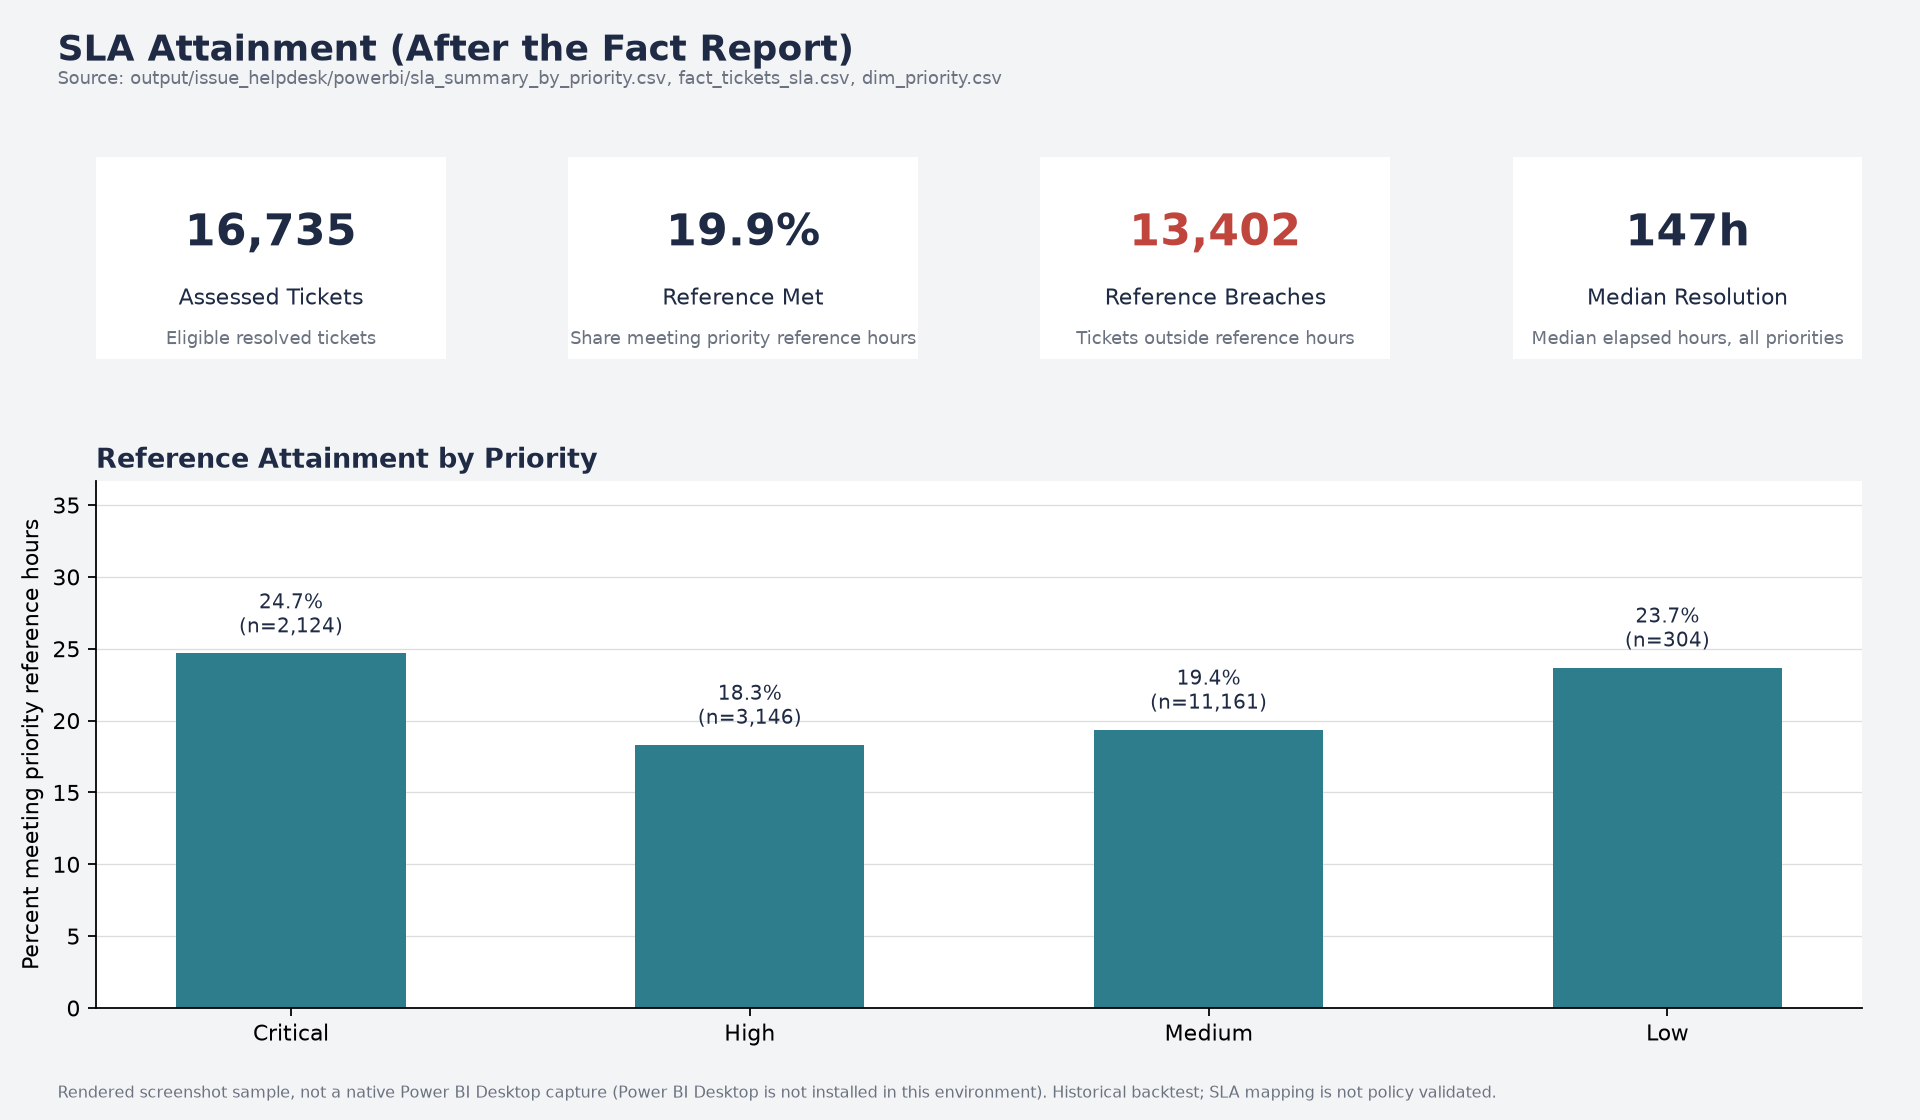

daily_volume_and_forecast


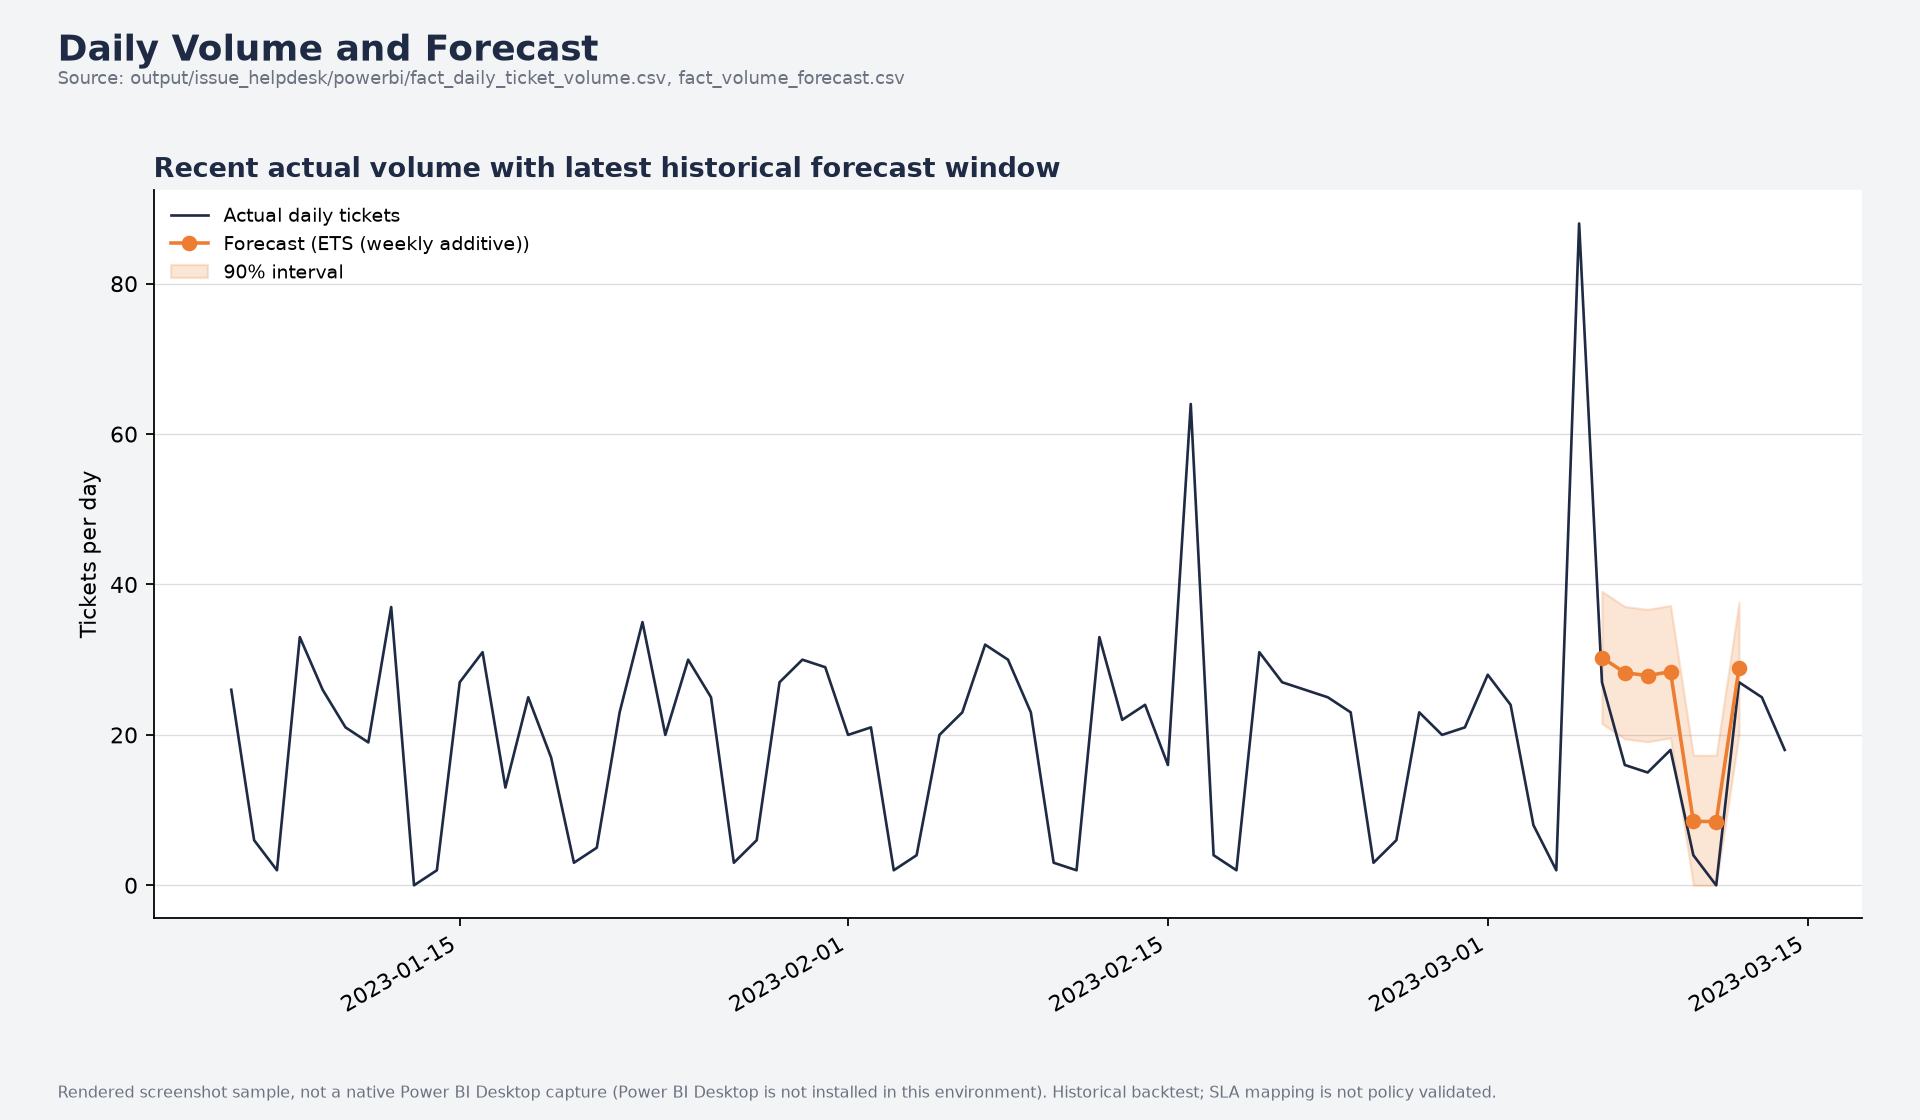

model_comparison


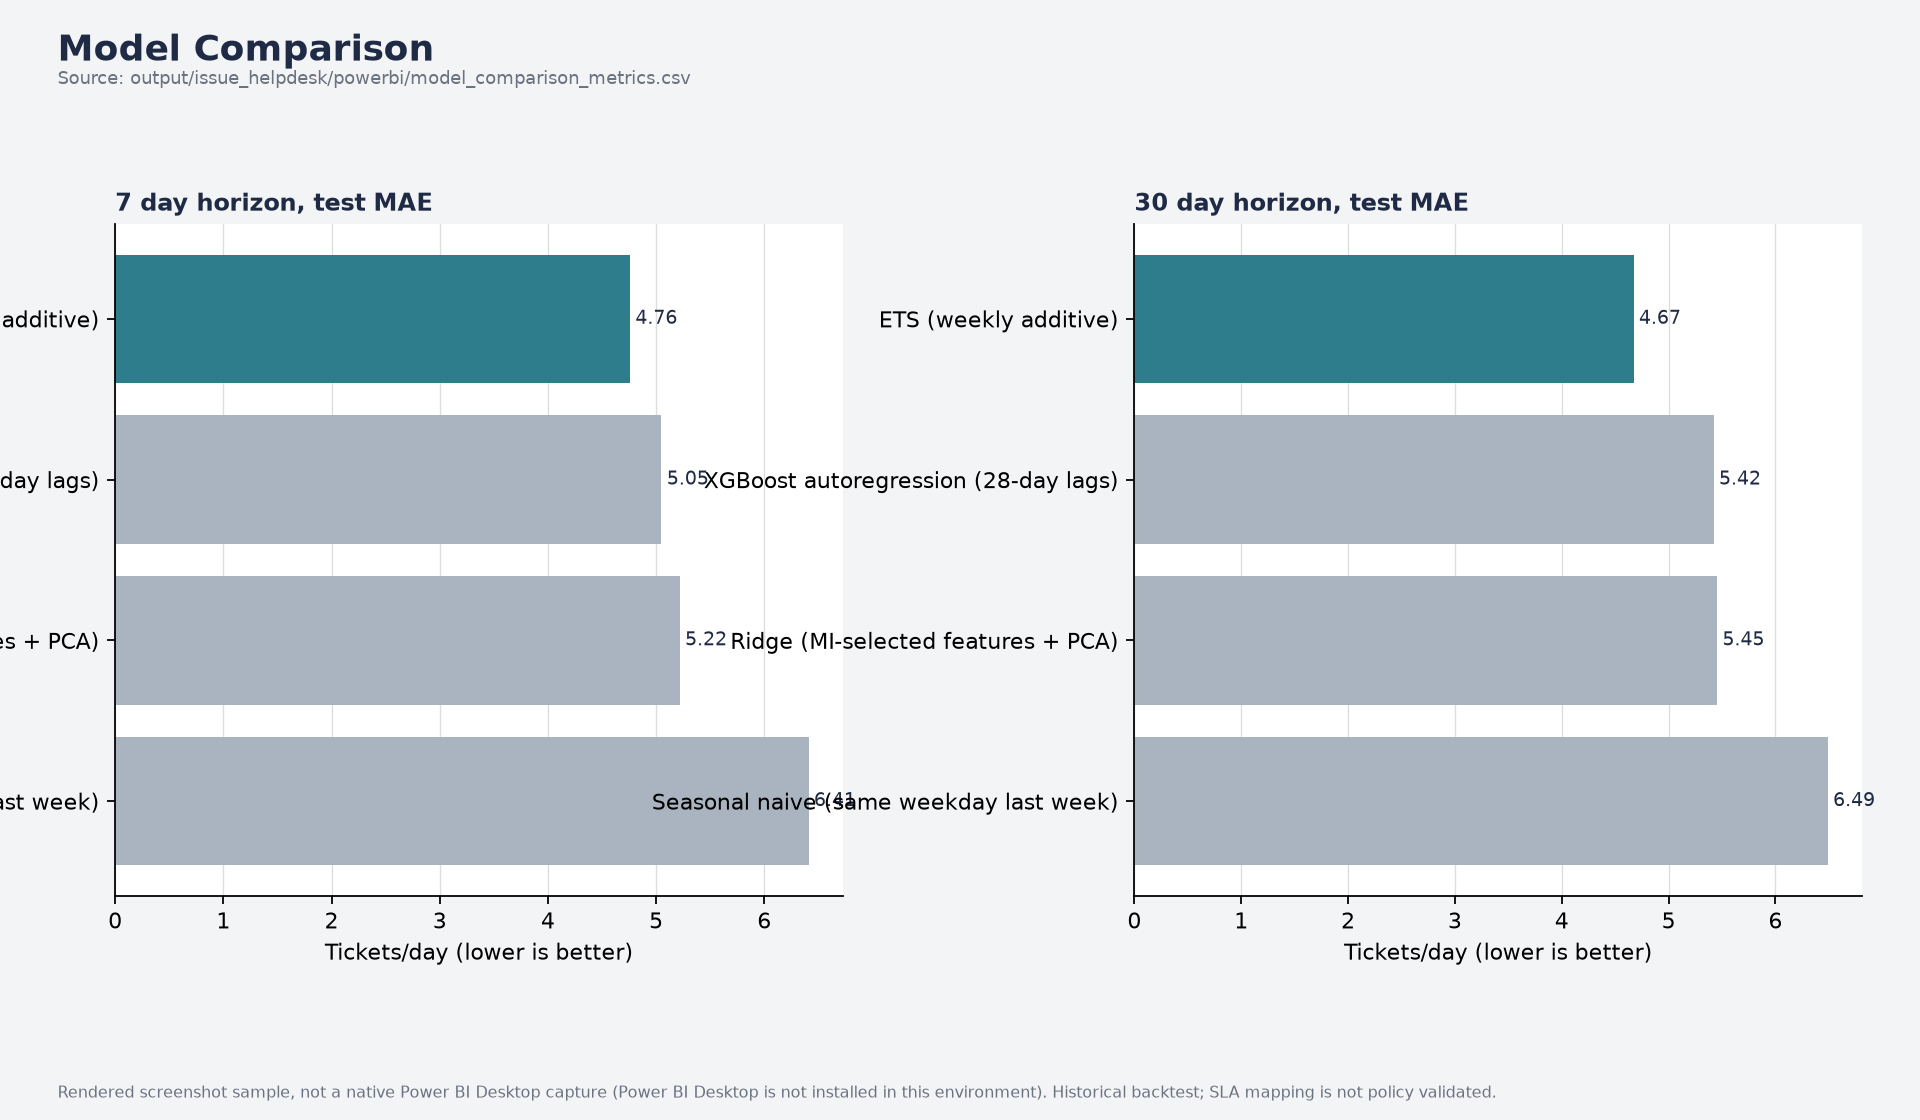

data_contract_and_caveats


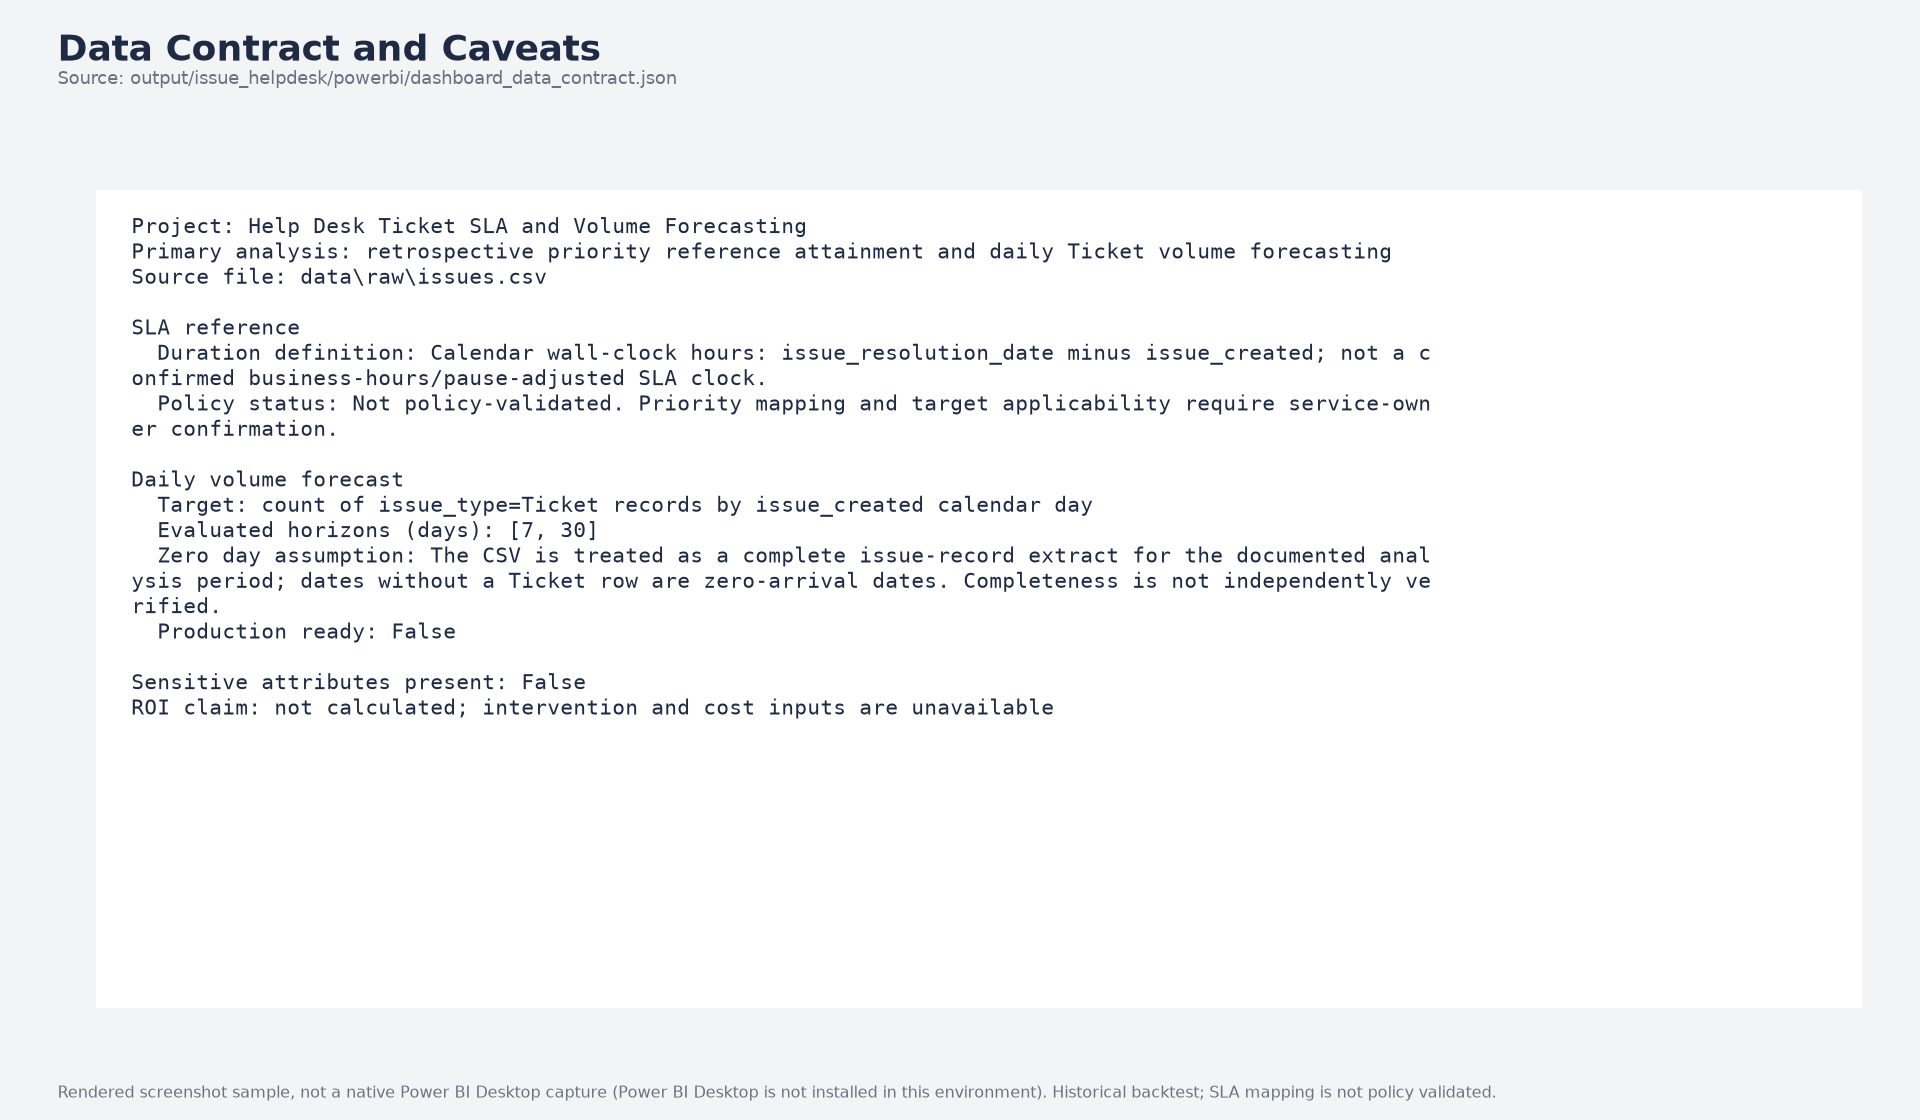

In [3]:
from IPython.display import Image, display

for name, path in powerbi_result["screenshots"].items():
    print(name)
    display(Image(filename=str(ROOT / path)))

## Integration contract

The forecast grain is one calendar date in UTC and the count includes only exact `Ticket` records in the 2016+ scope. The SLA assessment is a separate issue-level retrospective aggregate. Never mix a forecast count with an SLA rate or represent an SLA reference label as a live breach alert. Input data coverage, target mapping and the stated historical end date must travel with downstream extracts.

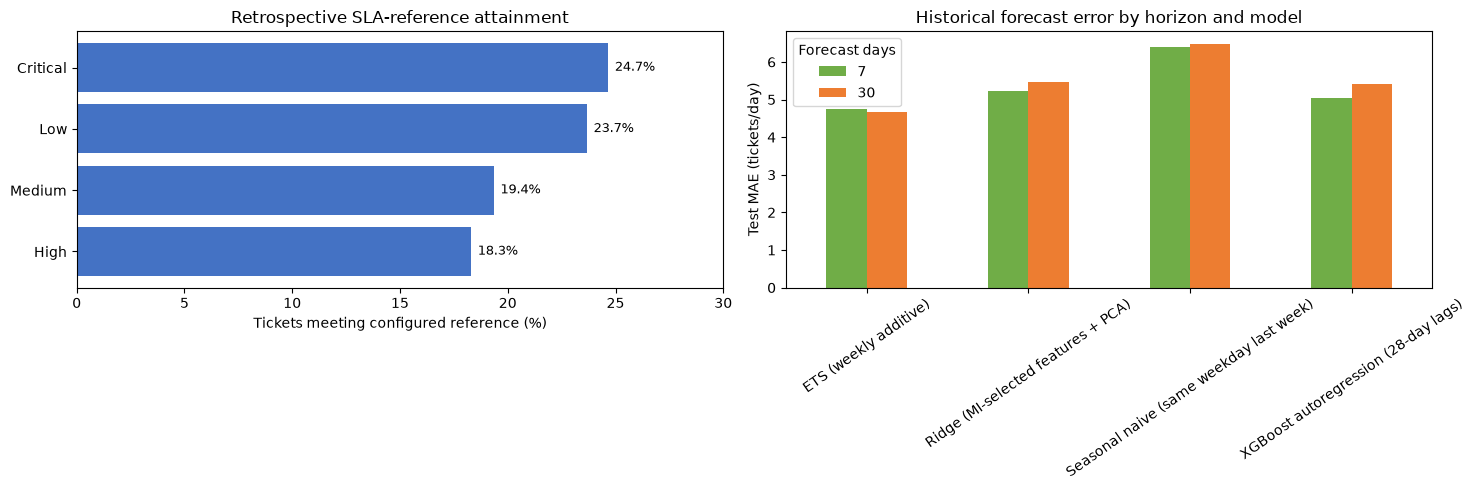

In [4]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
import matplotlib.pyplot as plt
from src.issues_capstone import PROJECT_REPORTS, REPORTS

sla = pd.read_csv(PROJECT_REPORTS / "sla_attainment_by_priority.csv")
sla = sla.loc[~sla["priority"].eq("Overall")].sort_values("reference_met_pct")
forecast_metrics = pd.read_csv(PROJECT_REPORTS / "dashboard_forecast_metrics.csv")
contract = result["contract"]["daily_volume_forecast"]
selected_models = contract["selected_models_by_horizon"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].barh(sla["priority"], sla["reference_met_pct"], color="#4472C4")
axes[0].set_xlabel("Tickets meeting configured reference (%)")
axes[0].set_title("Retrospective SLA-reference attainment")
axes[0].set_xlim(0, max(30, sla["reference_met_pct"].max() * 1.15))
for y, value in enumerate(sla["reference_met_pct"]):
    axes[0].text(value + 0.3, y, f"{value:.1f}%", va="center", fontsize=9)

test_metrics = forecast_metrics.loc[forecast_metrics["split"].eq("test")].copy()
pivot = test_metrics.pivot(index="model", columns="forecast_window_days", values="MAE")
pivot = pivot[[7, 30]]
pivot.plot(kind="bar", ax=axes[1], color=["#70AD47", "#ED7D31"])
axes[1].set_ylabel("Test MAE (tickets/day)")
axes[1].set_xlabel("")
axes[1].set_title("Historical forecast error by horizon and model")
axes[1].legend(title="Forecast days")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()


In [5]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import pandas as pd
from IPython.display import display
from src.issues_capstone import PROJECT_REPORTS, REPORTS

contract = result["contract"]["daily_volume_forecast"]
selected_models = contract["selected_models_by_horizon"]
metrics = pd.read_csv(PROJECT_REPORTS / "dashboard_forecast_metrics.csv")
selected_test = []
for horizon in [7, 30]:
    chosen = selected_models[str(horizon)]["selected_model"]
    row = metrics.loc[
        metrics["split"].eq("test")
        & metrics["forecast_window_days"].eq(horizon)
        & metrics["model"].eq(chosen)
    ].iloc[0]
    selected_test.append({
        "horizon_days": horizon,
        "selected_model": chosen,
        "test_MAE_tickets_per_day": row["MAE"],
        "test_RMSE_tickets_per_day": row["RMSE"],
        "test_WAPE": row["WAPE"],
        "test_interval_coverage": row["coverage_90_interval"],
    })
print("Selected model performance on the historical test period:")
display(pd.DataFrame(selected_test).round(3))

predictions = pd.read_csv(REPORTS / "volume_forecast_rolling_predictions.csv")
example_rows = []
for horizon in [7, 30]:
    chosen = selected_models[str(horizon)]["selected_model"]
    selected = predictions.loc[
        predictions["split"].eq("test")
        & predictions["forecast_window_days"].eq(horizon)
        & predictions["model"].eq(chosen)
    ].copy()
    selected["origin_date"] = pd.to_datetime(selected["origin_date"], utc=True)
    latest_origin = selected["origin_date"].max()
    example_rows.append(selected.loc[selected["origin_date"].eq(latest_origin)].head(5))
sample = pd.concat(example_rows, ignore_index=True)
sample["origin_date"] = pd.to_datetime(sample["origin_date"], utc=True).dt.strftime("%Y-%m-%d")
sample["forecast_date"] = pd.to_datetime(sample["forecast_date"], utc=True).dt.strftime("%Y-%m-%d")
display(sample[[
    "forecast_window_days", "model", "origin_date", "forecast_date", "horizon_days",
    "actual_tickets", "forecast_tickets", "forecast_lower_90", "forecast_upper_90",
]].round(1))


Selected model performance on the historical test period:


,horizon_days,selected_model,test_MAE_tickets_per_day,test_RMSE_tickets_per_day,test_WAPE,test_interval_coverage
0,7,XGBoost autoregression (28-day lags),5.049,7.722,0.304,0.866
1,30,ETS (weekly additive),4.672,7.197,0.275,0.877


,forecast_window_days,model,origin_date,forecast_date,horizon_days,actual_tickets,forecast_tickets,forecast_lower_90,forecast_upper_90
0,7,XGBoost autoregression (28-day lags),2023-03-05,2023-03-06,1,27.0,25.4,16.0,34.7
1,7,XGBoost autoregression (28-day lags),2023-03-05,2023-03-07,2,16.0,23.7,14.3,33.0
2,7,XGBoost autoregression (28-day lags),2023-03-05,2023-03-08,3,15.0,23.1,13.8,32.5
3,7,XGBoost autoregression (28-day lags),2023-03-05,2023-03-09,4,18.0,21.4,12.1,30.8
4,7,XGBoost autoregression (28-day lags),2023-03-05,2023-03-10,5,4.0,7.2,0.0,16.5
5,30,ETS (weekly additive),2023-02-12,2023-02-13,1,22.0,27.4,18.3,36.5
6,30,ETS (weekly additive),2023-02-12,2023-02-14,2,24.0,25.0,15.9,34.1
7,30,ETS (weekly additive),2023-02-12,2023-02-15,3,16.0,24.6,15.5,33.7
8,30,ETS (weekly additive),2023-02-12,2023-02-16,4,64.0,23.3,14.1,32.4
9,30,ETS (weekly additive),2023-02-12,2023-02-17,5,4.0,5.1,0.0,14.3


## How to read the graph and sample output

The left panel summarizes historical completed-ticket attainment against the configured priority references; these are retrospective comparisons, not confirmed contractual SLA compliance. The right panel compares held-out historical daily forecast MAE for the 7- and 30-day paths; lower is better, and both horizons select models independently using validation MAE. A 30-day path is 30 daily estimates, not one monthly total.

The tables show horizon-specific held-out metrics and five example daily predictions from the latest available historical test origin for each selected model. `actual_tickets` is included only because this is a backtest; in live forecasting it would be unknown. Interval bounds are empirical validation-calibrated bounds and are shown for test rows only. The sample dates come from data ending March 2023, so this output demonstrates the reporting shape and historical test performance—not a current forecast. Data coverage, zero-arrival days, and SLA policy remain unverified.

## Dashboard proof of work

Power BI Desktop is not installed in this working environment, so a native `.pbix` screenshot could not be captured here. To still provide a visual proof artifact, the image below is rendered directly from this project's current dashboard data (`dashboard_sla_summary.csv` and `dashboard_forecast_metrics.csv`), styled to look like a BI report page with KPI cards and charts. It uses the same figures a Power BI report built on `dashboard_data_contract.json` would show.

Wrote C:\Users\acbitor\PycharmProjects\PythonProject for AIM\output\issue_helpdesk\dashboard_proof_visual.png


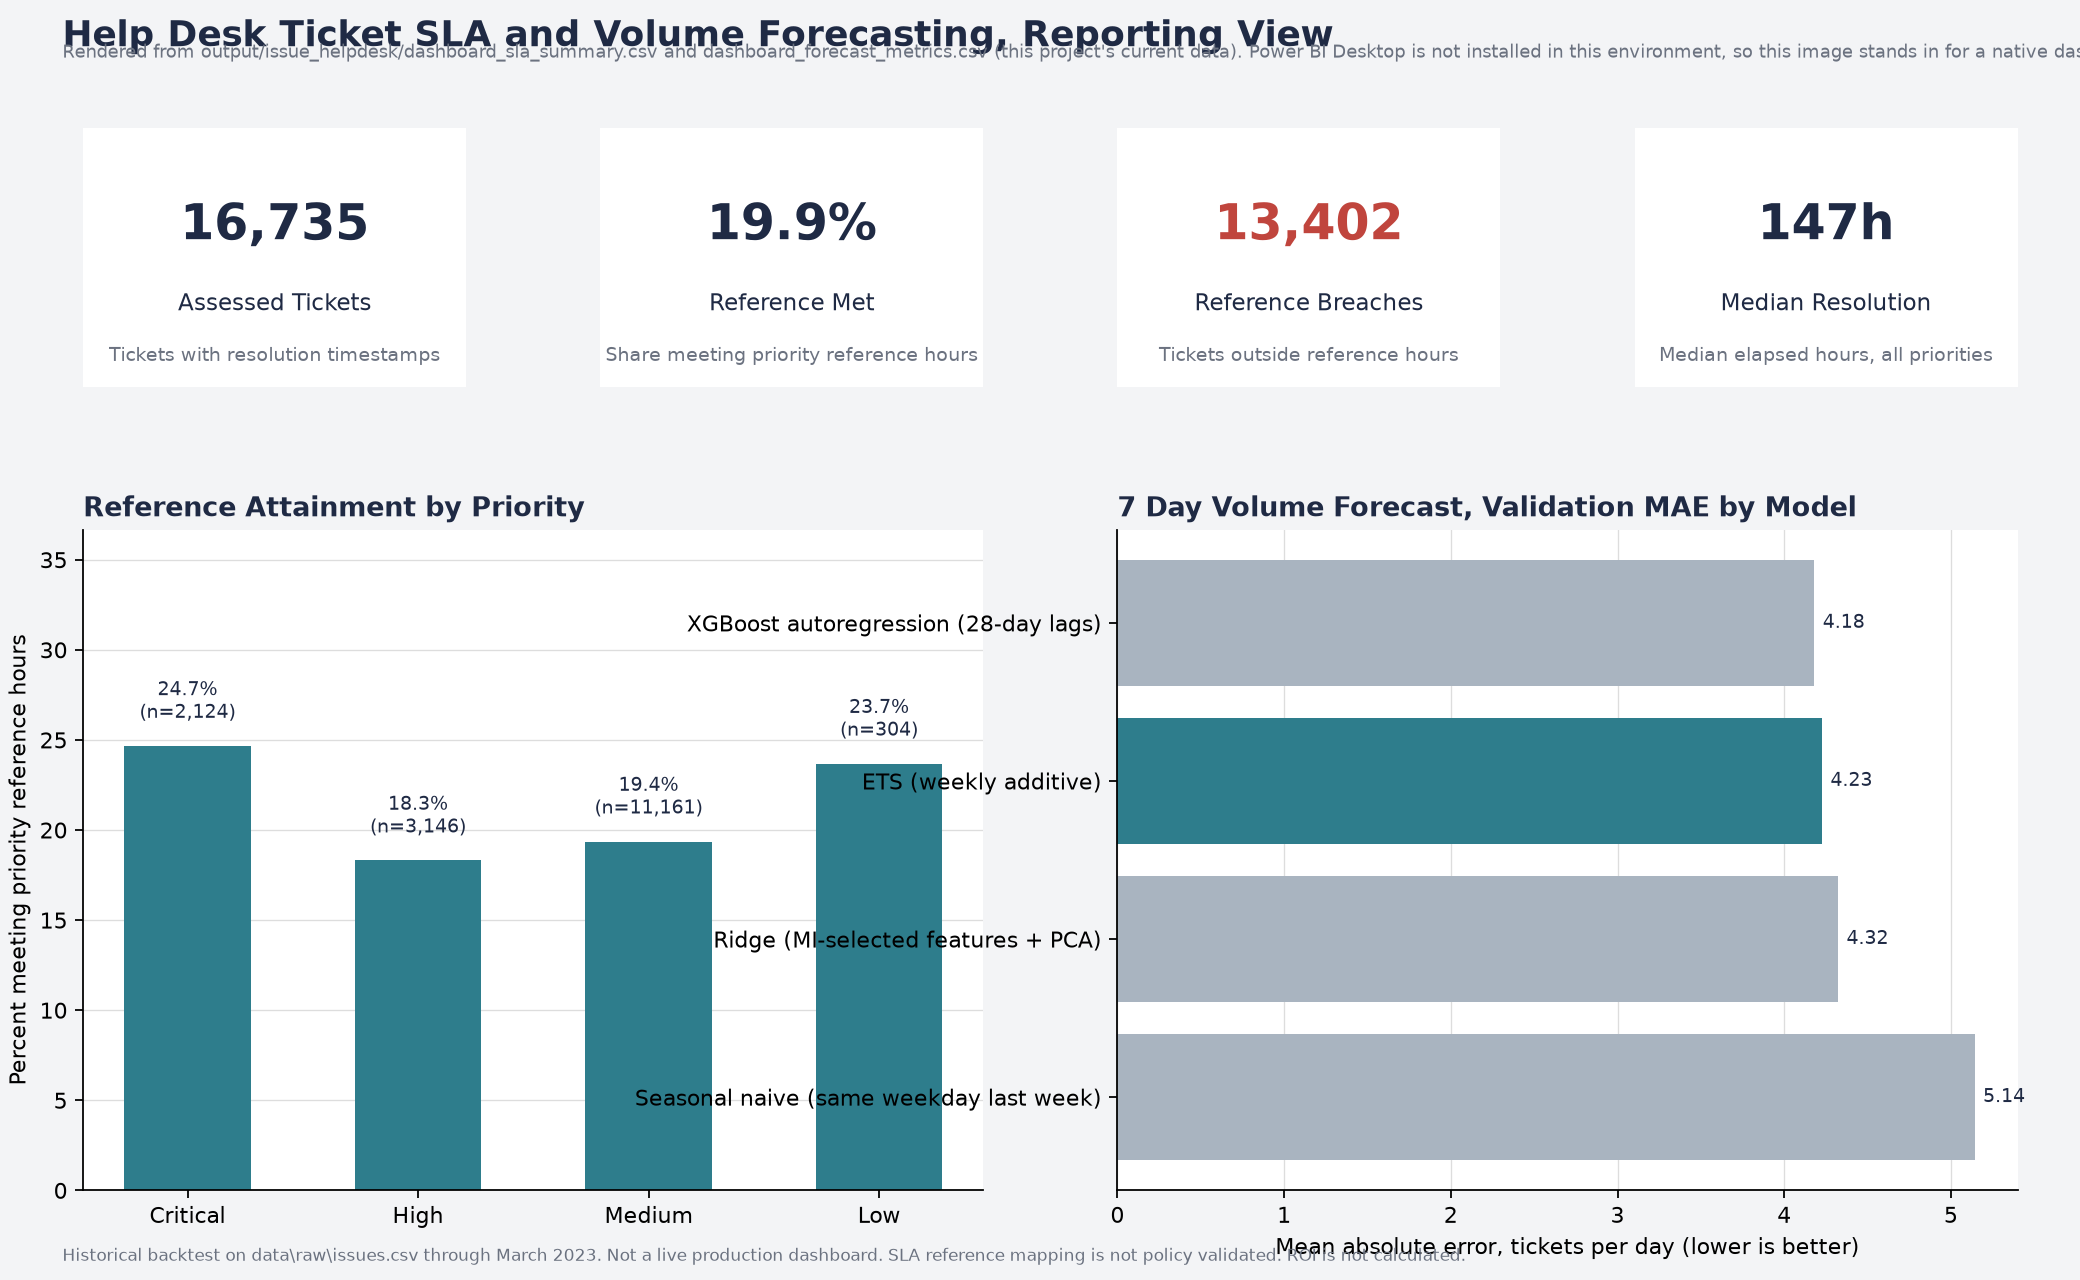

In [6]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.generate_dashboard_proof_image import build_dashboard, IMG_PATH

build_dashboard()

from IPython.display import Image
Image(filename=str(IMG_PATH))

## In summary

This notebook packages the two main results, the retrospective SLA comparison and the forecast experiment, into a clean, well documented data contract meant for a dashboard or reporting tool. It is not a live system and does not call any AI model to generate content; it simply defines what each number means, where it comes from, and what it should not be confused with, so anyone building a dashboard on top of this project understands the data correctly.